## Comparação: RoTHP vs RoTHP Hybrid vs THP Tradicional

Neste notebook, comparamos três variantes de modelos de Processos de Hawkes Neurais:

1. **RoTHP Original**: Usa Rotary Embeddings (RoPE) apenas nas Queries e Keys da atenção.
2. **RoTHP Hybrid**: Usa RoPE na atenção + Embedding Sinusoidal na entrada (para os Values).
3. **THP Tradicional**: Usa Embedding Sinusoidal Absoluto somado à entrada (sem RoPE).

**Objetivo:** Analisar como diferentes estratégias de codificação posicional afetam a convergência e a performance em dados sintéticos.

In [1]:
import sys
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

project_root = '/Users/hugoramossoares/Sites/EasyTemporalPointProcess'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Importando os modelos
from easy_tpp.model.torch_model.torch_rothp import RoTHP
from easy_tpp.model.torch_model.torch_rothp_hybrid import RoTHPHybrid
from easy_tpp.model.torch_model.torch_thp import THP
# from easy_tpp.model.torch_model.torch_nhp import NHP

from hawkes_data_utils import simulate_hawkes, prepare_batch

print("Modelos carregados com sucesso!")

Modelos carregados com sucesso!


In [6]:
# =============================================================================
# GERAÇÃO DE DADOS
# =============================================================================
HAWKES_MU = 0.3
HAWKES_ALPHA = 0.6
HAWKES_BETA = 1.3

NUM_TRAIN_SEQS = 2000
NUM_TEST_SEQS = 500
T_MAX = 100.0

torch.manual_seed(42)
print("Gerando dados...")
train_raw = simulate_hawkes(HAWKES_MU, HAWKES_ALPHA, HAWKES_BETA, NUM_TRAIN_SEQS, T_MAX, seed=42)
test_raw = simulate_hawkes(HAWKES_MU, HAWKES_ALPHA, HAWKES_BETA, NUM_TEST_SEQS, T_MAX, seed=123)

batch_train = prepare_batch(train_raw)
batch_test = prepare_batch(test_raw)

print(f"Dados prontos: {len(train_raw)} treino, {len(test_raw)} teste.")

Gerando dados...
Dados prontos: 2000 treino, 500 teste.
[[3.974240478270352, 4.260111678400409, 5.227614519272587, 10.655926912712996, 12.042498712921773, 12.855319837940762, 13.51877485531154, 20.294556828420657, 20.79346184937888, 21.07995871153999, 21.143129149785707, 21.420416155788672, 21.683584306889838, 25.90499390710974, 26.325439504432598, 27.93281650849952, 30.136972488605018, 31.99560192337441, 39.58346802282571, 44.81894147573682, 46.42062658560921, 46.642139886935794, 46.71369536536653, 47.245481450085066, 47.72262633271834, 47.822964192269346, 48.00662580888667, 48.356567933540674, 50.18143120192189, 50.51961466730822, 54.07509329309717, 54.25498444056876, 54.45417198500585, 54.96709292581762, 55.20442098159597, 58.82692240131614, 59.24359862202928, 59.39282730399265, 59.63771592691202, 60.090115168967216, 60.09161545266527, 61.0775116977073, 61.31122374803508, 63.146773707629784, 68.07554787925834, 78.0212055611158, 78.64256410487349, 79.15561640165132, 79.22844469622234

In [3]:
class ModelConfig:
    """Configuração compartilhada para ambos os modelos."""
    def __init__(self, hidden_size, num_heads, dropout):
        self.hidden_size = hidden_size
        self.time_emb_size = hidden_size
        # self.num_layers = 1
        self.num_layers = 4
        self.num_heads = num_heads
        self.dropout_rate = dropout
        self.use_ln = True
        self.num_event_types = 1
        self.num_event_types_pad = 2
        self.pad_token_id = 1
        self.loss_integral_num_sample_per_step = 20
        self.use_mc_samples = False
        self.gpu = -1
        self.thinning = None
        # self.model_specs = {'beta': 1.0, 'bias': True} # pro neural hawkes process.. NHP

def train_model(model_class, name, config, epochs=80, batch_size=64, lr=0.001):
    print(f"\n>>> Treinando {name}...")
    
    torch.manual_seed(42)
    model = model_class(config)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=8)
    
    te_hist = []
    tr_hist = []
    best_val = float('inf')
    best_ep = 0
    
    for epoch in range(1, epochs + 1):
        model.train()
        indices = np.random.permutation(len(train_raw))
        total_loss = 0
        total_events = 0
        
        for i in range(0, len(train_raw), batch_size):
            batch_idx = indices[i:i+batch_size]
            batch_seqs = [train_raw[k] for k in batch_idx]
            batch_data = prepare_batch(batch_seqs)
            
            optimizer.zero_grad()
            loss, num_events = model.loglike_loss(batch_data)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            total_loss += loss.item()
            total_events += num_events
            
        nll_train = total_loss / total_events
        tr_hist.append(nll_train)
        
        model.eval()
        with torch.no_grad():
            loss_test, num_test = model.loglike_loss(batch_test)
            nll_test = (loss_test / num_test).item()
            te_hist.append(nll_test)
            
        scheduler.step(nll_test)
        
        if nll_test < best_val:
            best_val = nll_test
            best_ep = epoch
            
        if epoch % 10 == 0:
            print(f"    Ep {epoch:2d} | Train: {nll_train:.4f} | Test: {nll_test:.4f}")
            
    print(f"    >>> Melhor Resultado: {best_val:.4f} (Ep {best_ep})")
    return {'test': te_hist, 'best': best_val, 'best_ep': best_ep}

In [4]:
# =============================================================================
# COMPARAÇÃO
# =============================================================================

# Configuração 'Tiny'
config = ModelConfig(hidden_size=8, num_heads=1, dropout=0.2)
# LR = 0.001
LR = 0.0005

# 1. Treinar RoTHP Original
res_original = train_model(RoTHP, "RoTHP Original", config, lr=LR)

# 2. Treinar RoTHP Hybrid
# res_hybrid = train_model(RoTHPHybrid, "RoTHP Hybrid", config, lr=LR)

# 3. Treinar THP Tradicional
# res_thp = train_model(THP, "THP Tradicional", config, lr=LR)

# 4. Neural Hawkes Process (NHP)
# hist_nhp = train_eval_loop(NHP, "Neural Hawkes (NHP)", config, train_data, test_data, epochs=30, patience=5)


>>> Treinando RoTHP Original...
    Ep 10 | Train: 1.1741 | Test: 1.0603
    Ep 20 | Train: 0.7078 | Test: 1.8428
    Ep 30 | Train: 0.5629 | Test: 2.9800
    Ep 40 | Train: 0.4889 | Test: 4.0084
    Ep 50 | Train: 0.4622 | Test: 4.3787
    Ep 60 | Train: 0.4700 | Test: 4.6274
    Ep 70 | Train: 0.4784 | Test: 4.7631
    Ep 80 | Train: 0.4267 | Test: 4.7901
    >>> Melhor Resultado: 0.9880 (Ep 14)


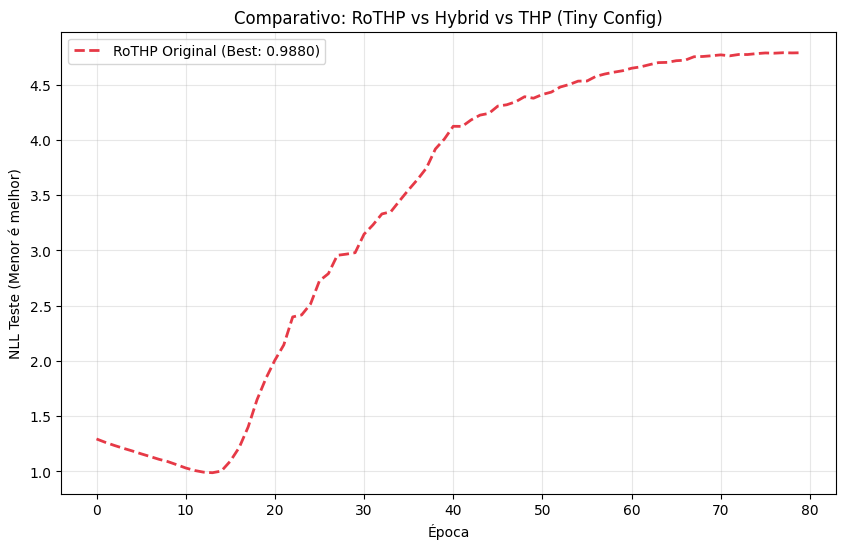

In [5]:
plt.figure(figsize=(10, 6))

plt.plot(res_original['test'], label=f"RoTHP Original (Best: {res_original['best']:.4f})", color='#E63946', linewidth=2, linestyle='--')
# plt.plot(res_hybrid['test'], label=f"RoTHP Hybrid (Best: {res_hybrid['best']:.4f})", color='#2E86AB', linewidth=2)
# plt.plot(res_thp['test'], label=f"THP Tradicional (Best: {res_thp['best']:.4f})", color='green', linewidth=2, linestyle='-.')

plt.xlabel('Época')
plt.ylabel('NLL Teste (Menor é melhor)')
plt.title('Comparativo: RoTHP vs Hybrid vs THP (Tiny Config)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()